In [1]:
# Escrever um arquivo com a função open()

with open('dados.txt', 'w', encoding='utf-8') as f:
    f.write('Olá mundo')

In [2]:
# Ler um arquivo com a função open()

with open('dados.txt', 'r', encoding='utf-8') as f:
    conteudo = f.read()

print(conteudo)

Olá mundo


In [3]:
# Alterar um arquivo com a função open()

with open('dados.txt', 'a', encoding = 'utf-8') as f:
    f.write('\nÚltima linha')

In [4]:
import csv

with open('dados.csv', 'w', newline = '', encoding = 'utf-8') as f:
    escritor = csv.writer(f)
    escritor.writerow(['nome', 'idade'])
    escritor.writerow(['Ana', 32])
    escritor.writerow(['Carlos', 35])


In [5]:
with open('dados.csv', newline = '') as f:
    leitor = csv.reader(f)
    for linha in leitor:
        print(linha)

['nome', 'idade']
['Ana', '32']
['Carlos', '35']


In [6]:
import json

dados = {
    'nome': 'Ana',
    'idade': 32,
    'enderecos': ['a', 'b']
}

with open('dados.json', 'w', encoding = 'utf-8') as f:
    json.dump(dados, f)


In [7]:
with open('dados.json', 'r', encoding = 'utf-8') as f:
    dados_lidos = json.load(f)
    print(dados_lidos)

{'nome': 'Ana', 'idade': 32, 'enderecos': ['a', 'b']}


BANCO DE DADOS

In [11]:
import sqlite3

conn = sqlite3.connect('escola.db')
cursor = conn.cursor()

cursor.execute(
    '''
CREATE TABLE IF NOT EXISTS estudantes(
id INTEGER PRIMARY KEY,
nome TEXT,
idade INTEGER
)
'''
)

cursor.execute(
    '''
    INSERT INTO estudantes (nome, idade)
    VALUES (?, ?)
''',
('João', 20)
)

conn.commit()

cursor.execute(
    '''
    SELECT * FROM estudantes
    '''
)

print(cursor.fetchall())

conn.close()


[(1, 'João', 20)]


In [1]:
from pymongo import MongoClient

client = MongoClient('mongodb://172.17.80.1:27017/')  # o padrão é localhost em vez do IP... está assim pq estou no WSL executando mongo no windows

db = client['escola']
estudantes = db['estudantes']

estudantes.insert_one(
    {
        'nome': 'Pedro',
        'idade': 21
    }
)

for estudante in estudantes.find():
    print(estudante)

{'_id': ObjectId('6a9e1c060275867b11df244c'), 'nome': 'João', 'idade': 20}
{'_id': ObjectId('6a9e1c8c0275867b11df244e'), 'nome': 'João', 'idade': 20}
{'_id': ObjectId('6a9f33cda00295e6165ef69f'), 'nome': 'Pedro', 'idade': 21}


SQLITE3



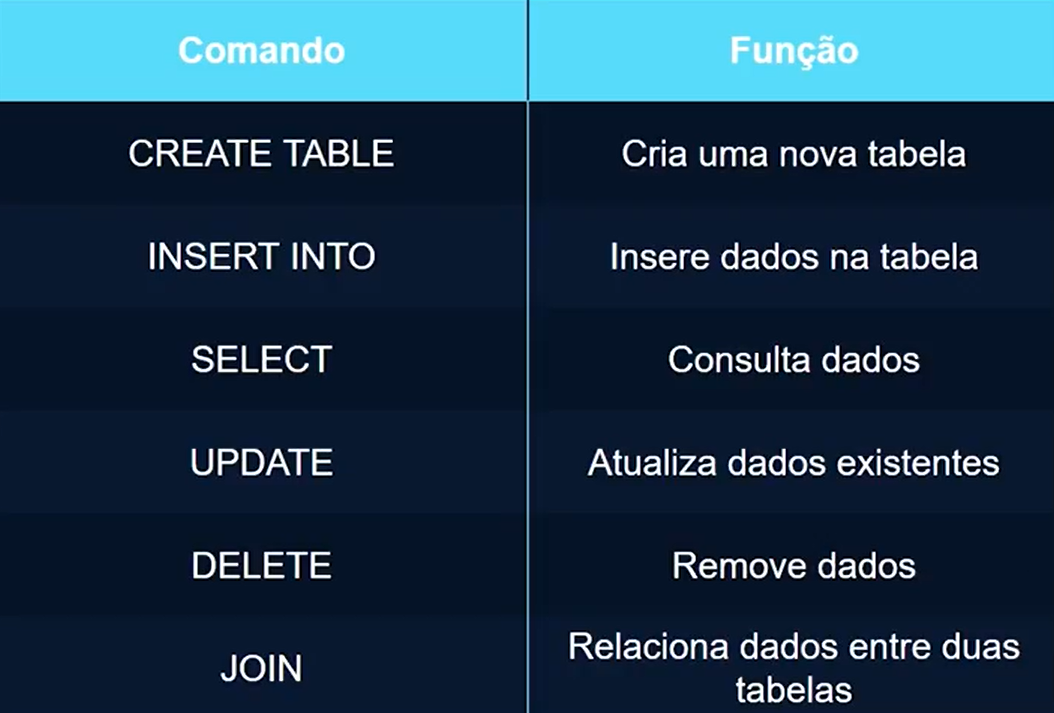

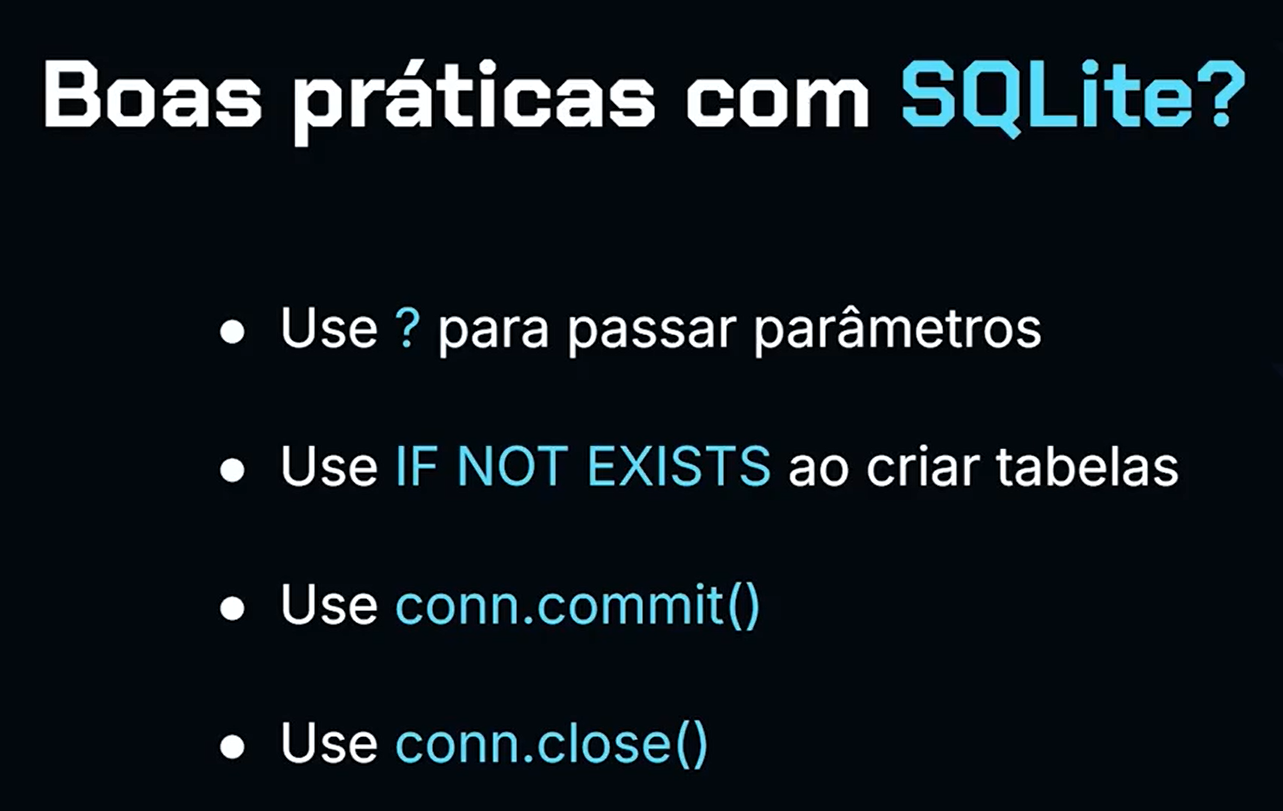

# Para saber mais: O que é SQL Injection

[Discussir no fórum](#)

SQL Injection (ou injeção de SQL) é uma técnica de ataque em que uma pessoa mal-intencionada insere comandos SQL maliciosos em campos de entrada, como formulários de login, buscas ou URLs, para manipular o banco de dados da aplicação.

Em vez de fornecer apenas um dado esperado, como um nome de usuário, o atacante injeta código SQL para:

- obter informações confidenciais, como senhas, e-mails e CPF;
- modificar dados, alterando ou excluindo registros;
- executar comandos administrativos, como derrubar tabelas ou criar usuários;
- assumir o controle da aplicação ou do servidor.

## Exemplo

Suponha que um login use um SQL inseguro como este:

```sql
SELECT * FROM usuarios
WHERE usuario = '" + entrada_usuario + "'
  AND senha = '" + entrada_senha + "';
```

Se o atacante digitar no campo de usuário:

```sql
' OR '1'='1
```

O SQL montado será:

```sql
SELECT * FROM usuarios WHERE usuario = '' OR '1'='1' AND senha = '';
```

Como `'1'='1'` é sempre verdadeiro, o banco retorna todos os usuários e o atacante consegue logar sem senha.

## Como se proteger

- usar queries preparadas (parametrizadas) em vez de concatenar strings em SQL;
- usar ORM seguro, como SQLAlchemy ou Django ORM;
- validar e higienizar entradas do usuário;
- aplicar o princípio do menor privilégio no banco.

Exemplo em Python com `sqlite3`:

```python
cursor.execute(
    "SELECT * FROM usuarios WHERE usuario = ? AND senha = ?",
    (usuario, senha)
)
```

Esses são alguns exemplos de como se proteger. Se quiser saber mais sobre injeção de SQL, consulte este material: [SQL Injection](https://www.alura.com.br/artigos/sql-injection-proteja-sua-aplicacao).